# Notebook 11: can the controller be made to matter?

In Notebook 8, choosing the intervention at random did as well as UCB1 or Q-learning (H3, H5). This notebook tests three changes aimed at the likely reasons, each against random choice.

| Idea | Likely reason the learner did not help | Change tested here |
|---|---|---|
| 1. Warm start | Each run starts from zero and gets only a few dozen decisions | Before each run, two warm-up runs on the **same training split**; the controller starts from what they learned (halved, at most 10 pulls' worth per arm). Only the controller's statistics are carried over, not subsets or populations. |
| 2. Moves that differ | The four moves all unstick the search about equally well | A 7-move pool: **FLIP-S** (flip 1–3 features, the old PERTURB), **FLIP-L** (flip 4–20), **DROP** (remove 1–3 selected), **SWAP** (exchange 1–2 selected for unselected), **RESTART**, **DO**, **HO** |
| 3. Context | The controller cannot see the state of the search | **LinUCB**, a contextual bandit that sees how much budget is used, how long the search has been stuck, population diversity, the best subset's size and whether the last move helped |

**Setup:** the Notebook 8 KNN protocol on the ten datasets that use it (five gene-expression, five medical tabular). Everything runs at **3× the budget** (3,060 evaluations, population 20) to give the controller more decisions, with ten seeds. The clinical data are excluded because one evaluation there takes about 3.6 s.

**Variants (all at 3× budget):**

| Variant | Moves | Controller | Warm start | Tests |
|---|---|---|---|---|
| Random, 4 moves | old 4 | random | – | baseline for idea 1 (= Notebook 8's `Random arm (3x)`) |
| UCB1, 4 moves | old 4 | UCB1 | – | = RL-DOHO at 3× (Notebook 8's `UCB1 (3x)`) |
| Warm UCB1, 4 moves | old 4 | UCB1 | yes | **idea 1** |
| LinUCB, 4 moves | old 4 | LinUCB | – | idea 3 alone (secondary) |
| Random, 7 moves | new 7 | random | – | baseline for ideas 2 and 3 |
| UCB1, 7 moves | new 7 | UCB1 | – | **idea 2** |
| Warm UCB1, 7 moves | new 7 | UCB1 | yes | ideas 1 + 2 (secondary) |
| LinUCB, 7 moves | new 7 | LinUCB | – | **idea 3** (with the pool where context should matter) |
| Warm LinUCB, 7 moves | new 7 | LinUCB | yes | **all three** |

The two 4-move baselines use exactly the Notebook 8 code and seeds (checked: identical subsets and results). If the Notebook 8 caches are in your Drive, they cost almost nothing to rerun.

**Default: H10a only.** `ONLY` in the config cell runs three variants: Random 4 moves, UCB1 4 moves (the current RL-DOHO) and Warm UCB1 4 moves. This takes about 1–1.5 hours for all ten datasets, or about 40 minutes each in two parallel sessions (`TABS` in one, `GENE` in the other). Hypotheses that were not run are reported as not run.

**Runtime with all nine variants (`ONLY = None`):** about 4–5 minutes per dataset and seed (nine 3,060-evaluation runs plus the warm-ups), so about 8–10 hours for all 100 in one session. Split it across Colab sessions instead: set `DATASETS` to part of the list in each one, for example `["WDBC", "Hepatitis", "Dermatology"]`, `["SPECTF", "Backache", "colon"]`, `["ALLAML", "lung"]` and `["GLIOMA", "GSE93272"]`. Each dataset saves to its own file, and every run is saved as soon as it finishes, so rerunning a cell resumes where it stopped. Run sections 7 onwards once, in any session, after all datasets are done.

### Hypotheses (fixed before any run of this notebook; every outcome is reported)

These were written after H3 and H5 showed no controller effect, so the choice of what to test was informed by those results. The settings below (move sizes, warm-up length, prior decay and cap, LinUCB α and context) are fixed now and are not tuned.

Each test is a pooled two-sided sign test on fitness over the 100 paired runs (10 datasets × 10 seeds), Holm-corrected over the four:
- **H10a (idea 1):** Warm UCB1, 4 moves vs Random, 4 moves.
- **H10b (idea 2):** UCB1, 7 moves vs Random, 7 moves.
- **H10c (idea 3):** LinUCB, 7 moves vs Random, 7 moves.
- **H10d (all three):** Warm LinUCB, 7 moves vs Random, 7 moves.

**Success rule, fixed in advance:** the controller "earns its place" only if at least one of H10a–d favours the learner at Holm p < 0.05 **and** that same variant is not significantly worse than UCB1, 4 moves (the current RL-DOHO).

**Reported without a hypothesis:**
- Every variant against UCB1, 4 moves (Holm-corrected).
- Random, 7 moves vs Random, 4 moves: does the new pool help by itself?
- Gene and tabular data separately, and test scores.
- Two diagnostics:
  - Do the moves differ? This is checked on the rewards each move earns under random choice.
  - Does a learner pick the moves that earn more?

**Fairness:** the warm-started variants see two extra runs' worth of experience (2 × 1,020 evaluations on the same training split). This extra cost is reported. Only the controller's statistics carry over, so any gain has to come from better choices. A difference below 1e-12 counts as a tie.

In [ ]:
# ================= 1. SETUP =================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os, time, pickle, warnings, urllib.request, gzip, math, hashlib, zipfile
import numpy as np, pandas as pd, scipy.io as sio, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, balanced_accuracy_score, precision_score, recall_score, accuracy_score
from scipy.stats import kruskal, spearmanr
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [ ]:
# ================= 2. CONFIG =================
ROOT      = '/content/drive/MyDrive' if IN_COLAB else '.'
OUT_DIR   = f"{ROOT}/rl_doho_results_v5_rl"                     # results of this notebook
KNN_DIR   = f"{ROOT}/rl_doho_results_v3_knn"                    # Notebook 8 (caches, data, 3x-budget runs)
V2_DIR    = f"{ROOT}/rl_doho_results_v2_genes"                  # Notebook 7 (gene caches, 3x-budget runs)
PREV_DIRS = [f"{ROOT}/rl_doho_results_hd", f"{ROOT}/rl_doho_results_ra", f"{ROOT}/rl_doho_results_baselines_hd", V2_DIR, KNN_DIR]
DATA_DIR  = f"{OUT_DIR}/data"
GENE      = ["colon", "ALLAML", "lung", "GLIOMA", "GSE93272"]
TAB       = {"WDBC": "breast_cancer_wisconsin_diagnostic", "Hepatitis": "hepatitis", "Dermatology": "dermatology",
             "SPECTF": "spectf", "Backache": "backache"}
TABS      = list(TAB)
DATASETS  = TABS + GENE              # to run in parallel: e.g. TABS in one Colab session and GENE in another
SEEDS     = list(range(10))
POP_SIZE  = 20
BUDGET    = POP_SIZE * 51            # 1,020: length of each warm-up run
LONG_BUDGET = 3 * BUDGET             # 3,060: every evaluated run
N_WARMUP  = 2                        # warm-up runs before a warm-started run (same training split, seeds 1000+s, 2000+s)
KNN_K, CV_FOLDS, TEST_SIZE = 5, 5, 0.3
ALPHA, BETA = 0.99, 0.01
N_TOP_RA  = 5000
SCORING   = {d: "accuracy" for d in GENE[:4]} | {"GSE93272": "balanced_accuracy"} | {d: "balanced_accuracy" for d in TABS}
VERBOSE   = False

# name -> (moves, controller, warm start)
VARIANTS = {
    "Random, 4 moves":      ("ARMS4", "random", False),
    "UCB1, 4 moves":        ("ARMS4", "ucb",    False),
    "Warm UCB1, 4 moves":   ("ARMS4", "ucb",    True),
    "LinUCB, 4 moves":      ("ARMS4", "linucb", False),
    "Random, 7 moves":      ("ARMS7", "random", False),
    "UCB1, 7 moves":        ("ARMS7", "ucb",    False),
    "Warm UCB1, 7 moves":   ("ARMS7", "ucb",    True),
    "LinUCB, 7 moves":      ("ARMS7", "linucb", False),
    "Warm LinUCB, 7 moves": ("ARMS7", "linucb", True),
}
# Which variants to run. Default: H10a only (warm start vs random, plus the current RL-DOHO as reference).
# The two 4-move baselines are mostly read from Notebook 8's cache, so the cost is the warm-started variant.
ONLY  = ["Random, 4 moves", "UCB1, 4 moves", "Warm UCB1, 4 moves"]   # set to None to run all nine variants
NAMES = ONLY if ONLY else list(VARIANTS)

FAST = False                         # True: 2 small datasets x 1 seed with small budgets, only to check the notebook runs
if FAST: DATASETS, SEEDS, BUDGET, LONG_BUDGET = ["Hepatitis", "colon"], [0], 200, 400

os.makedirs(DATA_DIR, exist_ok=True)
def init_for(D): return "sparse" if D > 100 else "dense"
def save_pkl(obj, path):
    tmp = path + ".tmp"
    with open(tmp, "wb") as f: pickle.dump(obj, f)
    os.replace(tmp, path)
def load_pkl(path):
    for p in (path, path + ".tmp"):
        if os.path.exists(p):
            try:
                with open(p, "rb") as f: return pickle.load(f)
            except Exception as e: print(f"WARNING: could not read {p} ({e})")
    return {}
print("Output folder:", OUT_DIR, "| datasets:", DATASETS, "| budget per run:", LONG_BUDGET)

Output folder: /content/drive/MyDrive/rl_doho_results_v5_rl | datasets: ['WDBC', 'Hepatitis', 'Dermatology', 'SPECTF', 'Backache', 'colon', 'ALLAML', 'lung', 'GLIOMA', 'GSE93272'] | budget per run: 3060


## 3. Data (the same files as Notebook 8; reused from your Drive when present)

In [ ]:
DATA = {}
def first_existing(paths, default): return next((p for p in paths if os.path.exists(p)), default)
URL = "https://raw.githubusercontent.com/jundongl/scikit-feature/master/skfeature/data/{}.mat"
for name in [d for d in DATASETS if d in GENE and d != "GSE93272"]:
    path = first_existing([f"{d}/data/{name}.mat" for d in PREV_DIRS], f"{DATA_DIR}/{name}.mat")
    if not os.path.exists(path): urllib.request.urlretrieve(URL.format(name), path)
    d = sio.loadmat(path); DATA[name] = (d["X"].astype(float), d["Y"].ravel())
if "GSE93272" in DATASETS:
    gpath = first_existing([f"{d}/data/GSE93272_series_matrix.txt.gz" for d in PREV_DIRS], f"{DATA_DIR}/GSE93272_series_matrix.txt.gz")
    if not os.path.exists(gpath):
        urllib.request.urlretrieve("https://ftp.ncbi.nlm.nih.gov/geo/series/GSE93nnn/GSE93272/matrix/GSE93272_series_matrix.txt.gz", gpath)
    chars = []
    with gzip.open(gpath, "rt") as f:
        for line in f:
            if line.startswith("!Sample_geo_accession"): gsm = [v.strip('"') for v in line.rstrip("\n").split("\t")[1:]]
            elif line.startswith("!Sample_characteristics_ch1"): chars.append([v.strip('"') for v in line.rstrip("\n").split("\t")[1:]])
            elif line.startswith("!series_matrix_table_begin"): break
        expr = pd.read_csv(f, sep="\t", index_col=0, comment="!")
    meta = pd.DataFrame(index=gsm)
    for row in chars:
        keys = {v.split(":", 1)[0].strip() for v in row if ":" in v}
        if len(keys) == 1:
            k = keys.pop(); meta[k] = [v.split(":", 1)[1].strip() if ":" in v else None for v in row]
    meta["individual id"] = meta.get("individual id", pd.Series(meta.index, index=meta.index)).fillna(pd.Series(meta.index, index=meta.index))
    meta_k = meta[~meta["individual id"].duplicated(keep="first")]
    DATA["GSE93272"] = (expr[gsm][meta_k.index].T.values.astype(float), (meta_k["disease state"].str.upper() == "RA").astype(int).values)

PMLB = "https://media.githubusercontent.com/media/EpistasisLab/pmlb/master/datasets/{0}/{0}.tsv.gz"
SHA = {"breast_cancer_wisconsin_diagnostic": "b3845ddf3afff808cd6449daa546caf4d8b18f109b7ebb2344990e4c37fea291",
       "hepatitis": "87df1bbfb83b8204093ccd84ed18bb3695220c03aa4096f63a84cc5e136dbc0b",
       "dermatology": "c8852ba546e92249debecd9a897cda3f94fd10872fa13c62eb14ab40e279166e",
       "spectf": "664081130aa48fc189b2e1d3c44332f0b3eb1ee6d31b79af1643c137697677e4",
       "backache": "21d506c397dfeb3edbbbc253b923f59be6edb516689677ebef535296c6c62242"}
for short in [d for d in DATASETS if d in TABS]:
    name = TAB[short]
    path = first_existing([f"{KNN_DIR}/data/{name}.tsv.gz"], f"{DATA_DIR}/{name}.tsv.gz")
    if not os.path.exists(path): urllib.request.urlretrieve(PMLB.format(name), path)
    if hashlib.sha256(open(path, "rb").read()).hexdigest() != SHA[name]: print(f"WARNING: {name} checksum differs from Notebook 8's file")
    df = pd.read_csv(path, sep="\t")
    DATA[short] = (df.drop(columns="target").values.astype(float), pd.factorize(df["target"], sort=True)[0])
pd.DataFrame([{"dataset": n, "samples": X.shape[0], "features": X.shape[1], "classes": len(np.unique(y))} for n, (X, y) in DATA.items()])

,dataset,samples,features,classes
0,colon,62,2000,2
1,ALLAML,72,7129,2
2,lung,203,3312,5
3,GLIOMA,50,4434,4
4,GSE93272,101,54613,2
5,WDBC,569,30,2
6,Hepatitis,155,19,2
7,Dermatology,366,34,6
8,SPECTF,349,44,2
9,Backache,180,32,2


## 4. Fitness and test evaluation (identical to Notebook 8; earlier caches are reused because the fitness is deterministic)

In [ ]:
def mask_str(m): return np.packbits(np.asarray(m, dtype=np.uint8)).tobytes().hex()
NEW_EVAL = {}
def use_dataset(name, seed):
    global X_tr, X_te, y_tr, y_te, N_FEATURES, _cache, CV, CUR, SCORE
    X, y = DATA[name]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=seed)
    if name == "GSE93272":
        col_mean = np.nanmean(X_tr, axis=0)
        X_tr = np.where(np.isnan(X_tr), col_mean, X_tr); X_te = np.where(np.isnan(X_te), col_mean, X_te)
        top = np.argsort(X_tr.var(axis=0))[-N_TOP_RA:]; X_tr, X_te = X_tr[:, top], X_te[:, top]
    sc = MinMaxScaler().fit(X_tr); X_tr, X_te = sc.transform(X_tr), sc.transform(X_te)
    N_FEATURES = X_tr.shape[1]
    CV = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=seed); SCORE = SCORING[name]; CUR = (name, seed)
    _cache = {}
    for d in PREV_DIRS + [OUT_DIR]:
        c = load_pkl(f"{d}/cache_{name}_s{seed}.pkl")
        if c: _cache.update(c)
def save_cache_now(): save_pkl(_cache, f"{OUT_DIR}/cache_{CUR[0]}_s{CUR[1]}.pkl")

def fitness_function(mask):
    key = mask_str(mask)
    if key in _cache: return _cache[key]["fit"]
    sel = np.flatnonzero(mask)
    if len(sel) == 0:
        _cache[key] = {"fit": 1.0, "acc": 0.0}; return 1.0
    t0 = time.perf_counter()
    acc = cross_val_score(KNeighborsClassifier(KNN_K), X_tr[:, sel], y_tr, cv=CV, scoring=SCORE).mean()
    f = ALPHA * (1 - acc) + BETA * len(sel) / len(mask)
    _cache[key] = {"fit": f, "acc": acc}
    c = NEW_EVAL.setdefault(CUR[0], [0, 0.0]); c[0] += 1; c[1] += time.perf_counter() - t0
    return f

def test_metrics(mask):
    sel = np.flatnonzero(mask)
    p = KNeighborsClassifier(KNN_K).fit(X_tr[:, sel], y_tr).predict(X_te[:, sel])
    acc = balanced_accuracy_score(y_te, p) if SCORE == "balanced_accuracy" else accuracy_score(y_te, p)
    return {"test_acc": float(acc), "test_prec": float(precision_score(y_te, p, average="macro", zero_division=0)),
            "test_rec": float(recall_score(y_te, p, average="macro", zero_division=0)), "test_f1": float(f1_score(y_te, p, average="macro"))}
print("Fitness ready.")

Fitness ready.


## 5. Algorithms: the Notebook 8 code, unchanged, plus the Notebook 11 controllers and move pool

In [ ]:
# ===================== RL-DOHO v2: shared algorithm code =====================
# Every method gets the same number of FITNESS EVALUATIONS (not iterations), because the
# published HO evaluates about 3N candidates per iteration while DO evaluates N.
# Encoding: continuous position x in [LB, UB]^D, feature j selected if sigmoid(x_j) > 0.5 (i.e. x_j > 0).
import math, time
import numpy as np, pandas as pd

LB, UB = -3.0, 3.0

class BudgetExhausted(Exception):
    pass

def binarize(x):
    return (np.asarray(x) > 0).astype(np.int8)          # identical to sigmoid(x) > 0.5

def mkey(mask):
    return np.packbits(np.asarray(mask, dtype=np.uint8)).tobytes()

class Problem:
    """Wraps a (cached, deterministic) fitness function and enforces the evaluation budget.
    Also records the time spent inside the fitness function (fsec) and the number of distinct
    subsets evaluated (len(seen)), so the algorithm's own overhead can be separated from fitness cost."""
    def __init__(self, fitness_fn, D, budget):
        self.fitness_fn, self.D, self.budget, self.calls = fitness_fn, D, budget, 0
        self.fsec, self.seen = 0.0, set()
    def left(self):
        return self.budget - self.calls
    def f(self, mask):
        if self.calls >= self.budget:
            raise BudgetExhausted
        self.calls += 1
        m = np.asarray(mask, dtype=np.int8); self.seen.add(mkey(m))
        t0 = time.perf_counter(); v = float(self.fitness_fn(m)); self.fsec += time.perf_counter() - t0
        return v
    def fx(self, x):
        return self.f(binarize(x))

# ------------------------------------------------------------------ initialisation
def init_population(rng, N, D, mode="dense"):
    """dense : x ~ U(-1, 1)  -> each feature selected with probability 0.5 (as in Notebooks 1-5).
       sparse: agent i keeps a fraction p_i ~ log-uniform[min(10/D, 0.1), 0.1] of the features
               (used when D > 100: ten features up to 10% of them)."""
    if mode == "dense":
        return rng.uniform(-1, 1, (N, D))
    lo, hi = math.log(min(10.0 / D, 0.1)), math.log(0.1)
    X = np.empty((N, D))
    for i in range(N):
        p = math.exp(rng.uniform(lo, hi))
        sel = rng.random(D) < p
        if not sel.any():
            sel[rng.integers(D)] = True
        X[i] = np.where(sel, rng.uniform(0.1, 1.0, D), -rng.uniform(0.1, 1.0, D))
    return X

def random_position(rng, D, mode):
    return init_population(rng, 1, D, mode)[0]

# ------------------------------------------------------------------ Levy flight (Mantegna)
def levy(rng, shape, beta=1.5):
    num = math.gamma(1 + beta) * math.sin(math.pi * beta / 2)
    den = math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2)
    sigma = (num / den) ** (1 / beta)
    u = rng.normal(0, sigma, shape); v = rng.normal(0, 1, shape)
    return u / np.abs(v) ** (1 / beta)

def lognpdf(x):                                          # lognormal pdf, mu = 0, sigma = 1
    x = np.maximum(x, 1e-300)
    return np.exp(-np.log(x) ** 2 / 2) / (x * math.sqrt(2 * math.pi))

# ------------------------------------------------------------------ Dandelion Optimizer (Zhao et al., 2022)
def do_move(rng, X, elite, t, T):
    """One full DO iteration: rising (Eqs. 2-8), descending (Eqs. 10-11), landing (Eqs. 12-14).
    Returns the new population; the caller evaluates it (N evaluations)."""
    N, D = X.shape
    T = max(T, 2); t = min(max(t, 1), T)
    alpha = rng.random() * ((t / T) ** 2 - 2 * t / T + 1)                     # Eq. 4: adaptive step
    a = 1.0 / (T ** 2 - 2 * T + 1); b = -2 * a; c = 1 - a - b
    k = 1 - rng.random() * (c + a * t ** 2 + b * t)                          # Eq. 8 (k with q)
    # --- rising stage
    if rng.standard_normal() < 1.5:                                          # clear weather
        lamb = np.abs(rng.standard_normal((N, D)))
        theta = (2 * rng.random(N) - 1) * math.pi
        r = 1 / np.exp(theta); vx = r * np.cos(theta); vy = r * np.sin(theta)
        Xs = rng.uniform(LB, UB, (N, D))                                     # Eq. 3: random position
        X1 = X + alpha * (vx * vy)[:, None] * lognpdf(lamb) * (Xs - X)       # Eq. 2
    else:                                                                    # rainy weather
        X1 = X * k                                                           # Eq. 7
    X1 = np.clip(X1, LB, UB)
    # --- descending stage (Brownian motion around the population mean)
    beta = rng.standard_normal((N, D))
    Xm = X1.mean(axis=0)                                                     # Eq. 11
    X2 = np.clip(X1 - beta * alpha * (Xm - beta * alpha * X1), LB, UB)      # Eq. 10
    # --- landing stage (Levy flight around the elite)
    step = 0.01 * levy(rng, (N, D))                                          # Eq. 13, s = 0.01, beta = 1.5
    delta = 2 * t / T                                                        # Eq. 14
    X3 = elite + step * alpha * (elite - X2 * delta)                         # Eq. 12
    return np.clip(X3, LB, UB)

# ------------------------------------------------------------------ Hippopotamus Optimization (Amiri et al., 2024)
def ho_iteration(rng, X, F, dominant, t, T, prob, on_eval):
    """One full HO iteration with greedy selection, updating X, F in place.
    Phase 1 (first half): male + female/immature candidates (Eqs. 3-9)      -> 2 evaluations per agent
    Phase 2 (second half): predator + defence candidate (Eqs. 10-16)        -> 2 evaluations per agent
    Phase 3 (all agents): escape within shrinking local bounds (Eqs. 17-19) -> 1 evaluation per agent
    on_eval(x, f) is called for every evaluated candidate that is a hippopotamus position."""
    N, D = X.shape
    half = N // 2
    T = max(T, 1); t = min(max(t, 1), T)
    for i in range(half):
        I1, I2 = rng.integers(1, 3, 2); rho = rng.integers(0, 2, 2)
        g = int(rng.integers(1, N + 1)); grp = rng.choice(N, g, replace=False)
        MG = X[grp].mean(axis=0)
        h = [I2 * rng.random(D) + (1 - rho[0]), 2 * rng.random(D) - 1, rng.random(D),
             I1 * rng.random(D) + (1 - rho[1]), rng.random()]                  # Eq. 4
        h1, h2 = h[rng.integers(5)], h[rng.integers(5)]
        x_m = np.clip(X[i] + rng.random() * (dominant - I1 * X[i]), LB, UB)     # Eq. 3 (male)
        if math.exp(-t / T) > 0.6:                                            # Eq. 5
            x_f = X[i] + h1 * (dominant - I2 * MG)                            # Eq. 6
        elif rng.random() > 0.5:
            x_f = X[i] + h2 * (MG - dominant)                                 # Eq. 7
        else:
            x_f = rng.uniform(LB, UB, D)
        x_f = np.clip(x_f, LB, UB)
        for x in (x_m, x_f):                                                  # Eqs. 8-9: greedy
            f = prob.fx(x); on_eval(x, f)
            if f < F[i]: X[i], F[i] = x, f
    for i in range(half, N):
        pred = rng.uniform(LB, UB, D)                                         # Eq. 10
        f_pred = prob.fx(pred)
        dist = np.abs(pred - X[i]) + 1e-12                                    # Eq. 11
        b_, c_, d_ = rng.uniform(2, 4), rng.uniform(1, 1.5), rng.uniform(2, 3)
        l_ = rng.uniform(-2 * math.pi, 2 * math.pi)                           # 2*pi*g with g in [-1, 1]
        RL = 0.05 * levy(rng, D)                                              # Eq. 13
        if F[i] > f_pred:
            x = RL * pred + (b_ / (c_ - d_ * math.cos(l_))) * (1 / dist)      # Eq. 12, case 1
        else:
            x = RL * pred + (b_ / (c_ - d_ * math.cos(l_))) * (1 / (2 * dist + rng.random(D)))
        x = np.clip(x, LB, UB)
        f = prob.fx(x); on_eval(x, f)
        if f < F[i]: X[i], F[i] = x, f                                        # Eqs. 15-16
    lo, hi = LB / t, UB / t                                                   # Eq. 17: local bounds
    for i in range(N):
        s = [2 * rng.random(D) - 1, rng.random(), rng.standard_normal()][rng.integers(3)]   # Eq. 19
        x = np.clip(X[i] + rng.random() * (lo + s * (hi - lo)), LB, UB)      # Eq. 18
        f = prob.fx(x); on_eval(x, f)
        if f < F[i]: X[i], F[i] = x, f                                        # Eq. 20

# ------------------------------------------------------------------ run bookkeeping
class Tracker:
    """Tracks the best subset found and logs one row per iteration."""
    def __init__(self, name, prob, verbose=False, tie_eps=0.0):
        self.name, self.prob, self.verbose, self.tie_eps = name, prob, verbose, tie_eps
        self.best_f, self.best_x, self.best_m = np.inf, None, None
        self.rows, self.t0 = [], time.time()
    def better(self, f, nf):
        if self.best_m is None: return True
        bf, bn = self.best_f, int(self.best_m.sum())
        e = self.tie_eps
        if e <= 0: return f < bf
        return f < bf - e or (abs(f - bf) <= e and (nf < bn or (nf == bn and f < bf)))
    def offer(self, x, f, mask=None):
        m = binarize(x) if mask is None else mask
        if self.better(f, int(m.sum())):
            self.best_f, self.best_x, self.best_m = f, (None if x is None else np.array(x, float)), m.copy()
            return True
        return False
    def log(self, it, action, F=None, reward=None):
        row = dict(iter=it, evals=self.prob.calls, action=action, best=self.best_f,
                   n_feats=int(self.best_m.sum()), pop_mean=(float(np.mean(F)) if F is not None else np.nan),
                   reward=reward, sec=time.time() - self.t0)
        self.rows.append(row)
        if self.verbose:
            rw = "" if reward is None else f"  r={reward:.3f}"
            print(f"  {self.name:<16} it {it:>3}  evals {self.prob.calls:>5}/{self.prob.budget}  {action:<10}"
                  f" best {self.best_f:.5f}  feats {row['n_feats']:>5}{rw}")
    def result(self):
        return {"mask": self.best_m, "fit": self.best_f, "hist": pd.DataFrame(self.rows)}

def _start(prob, rng, N, init, tr):
    X = init_population(rng, N, prob.D, init)
    F = np.array([prob.fx(x) for x in X])
    for x, f in zip(X, F): tr.offer(x, f)
    tr.log(0, "init", F)
    return X, F

# ------------------------------------------------------------------ DO, HO, DOHO (published update rules)
def run_do(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("DO", prob, verbose)
    T = max(2, (prob.budget - N) // N)
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            X = do_move(rng, X, tr.best_x, t, T)
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            tr.log(t, "DO", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_ho(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("HO", prob, verbose)
    T = max(1, math.ceil((prob.budget - N) / (3 * N)))
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            dom = X[np.argmin(F)].copy()
            ho_iteration(rng, X, F, dom, t, T, prob, tr.offer)
            tr.log(t, "HO", F)
    except BudgetExhausted:
        if tr.rows and tr.rows[-1]["evals"] != prob.calls: tr.log(len(tr.rows), "HO (partial)", F)
    return tr.result()

def run_doho(prob, N, seed, init="dense", verbose=False):
    """Fixed switch: published DO for the first half of the budget, then published HO."""
    rng = np.random.default_rng(seed); tr = Tracker("DOHO", prob, verbose)
    half_budget = prob.budget // 2
    T1 = max(2, (half_budget - N) // N); T2 = max(1, math.ceil((prob.budget - half_budget) / (3 * N)))
    it = 0
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T1 + 1):
            if prob.calls + N > half_budget: break
            X = do_move(rng, X, tr.best_x, t, T1)
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            it += 1; tr.log(it, "DO", F)
        for t in range(1, T2 + 1):
            ho_iteration(rng, X, F, X[np.argmin(F)].copy(), t, T2, prob, tr.offer)
            it += 1; tr.log(it, "HO", F)
    except BudgetExhausted:
        pass
    return tr.result()

# ------------------------------------------------------------------ controllers
class UCB1:
    def __init__(self, n_arms, seed, c=1.0):
        self.rng = np.random.default_rng(seed + 7919); self.c = c
        self.n = np.zeros(n_arms); self.v = np.zeros(n_arms)
    def choose(self, state=None):
        untried = np.flatnonzero(self.n == 0)
        if len(untried): return int(self.rng.choice(untried)), "i"
        ucb = self.v + self.c * np.sqrt(2 * np.log(self.n.sum()) / self.n)
        return int(self.rng.choice(np.flatnonzero(np.isclose(ucb, ucb.max())))), "u"
    def update(self, a, r):
        self.n[a] += 1; self.v[a] += (r - self.v[a]) / self.n[a]
    def finish(self):
        pass

class RandomArm(UCB1):
    def choose(self, state=None): return int(self.rng.integers(len(self.n))), "r"

class FixedArm(UCB1):
    def __init__(self, n_arms, seed, arm=0):
        super().__init__(n_arms, seed); self.arm = arm
    def choose(self, state=None): return self.arm, "f"

N_STATES = 6
def controller_state(calls, budget, last_gain):
    """State for the Q-learning controller: budget phase (first, second, last third) x whether the
    previous intervention improved the best subset (0/1) -> 6 states."""
    phase = min(2, int(3 * calls / budget))
    return 2 * phase + (1 if last_gain > 0 else 0)

class QLearn(UCB1):
    """Tabular one-step Q-learning over the arms. Epsilon-greedy (eps = 0.2), learning rate 0.3,
    discount 0.5, Q initialised at 0. The next state is the state at the next decision; the last
    decision of a run is updated without bootstrapping. Settings fixed in advance, not tuned."""
    def __init__(self, n_arms, seed, n_states=N_STATES, lr=0.3, gamma=0.5, eps=0.2):
        super().__init__(n_arms, seed)
        self.Q = np.zeros((n_states, n_arms)); self.lr, self.gamma, self.eps = lr, gamma, eps
        self.pending, self.s = None, 0
    def choose(self, state=0):
        if self.pending is not None:
            s, a, r = self.pending
            self.Q[s, a] += self.lr * (r + self.gamma * self.Q[state].max() - self.Q[s, a]); self.pending = None
        self.s = state
        if self.rng.random() < self.eps:
            return int(self.rng.integers(self.Q.shape[1])), "e"
        q = self.Q[state]
        return int(self.rng.choice(np.flatnonzero(np.isclose(q, q.max())))), "q"
    def update(self, a, r):
        self.n[a] += 1; self.pending = (self.s, a, r)
    def finish(self):
        if self.pending is not None:
            s, a, r = self.pending; self.Q[s, a] += self.lr * (r - self.Q[s, a]); self.pending = None

CONTROLLERS = {"ucb": UCB1, "random": RandomArm, "qlearn": QLearn}

ARMS = ("PERTURB", "RESTART", "DO", "HO")

# ------------------------------------------------------------------ RL-DOHO v2
def run_rldoho(prob, N, seed, init="dense", verbose=False, controller="ucb", reward="gain",
               kappa=2, tie_eps=1e-3, k_max=3, tabu_tries=20, intervene=True, name="RL-DOHO"):
    """DO (published) while the best improves; after `kappa` iterations without an accepted improvement,
    a controller picks one arm: PERTURB / RESTART (worse half, tabu) or one published DO / HO iteration.
    reward="gain": 0.8 * min(1, g / g_max) + 0.2 * share, where g = fitness gain of the best per evaluation
                   spent (parsimony-only moves give g = 0) and g_max = largest g seen so far in the run.
    reward="old" : 1 if the best changed, otherwise 0.2 * share (Notebooks 1-5)."""
    rng = np.random.default_rng(seed); D = prob.D
    tr = Tracker(name, prob, verbose, tie_eps=tie_eps)
    ctrl = CONTROLLERS.get(controller)
    ctrl = ctrl(len(ARMS), seed) if ctrl else FixedArm(len(ARMS), seed, arm=ARMS.index(controller))
    T_do = max(2, (prob.budget - N) // N); T_ho = max(1, math.ceil((prob.budget - N) / (3 * N)))
    def sched(T):                     # DO / HO schedules follow the share of the budget already spent
        return min(T, max(1, math.ceil(T * prob.calls / prob.budget)))
    tabu = set(); g_max = 0.0; stag = 0; it = 0; last_gain = 0.0
    arm_log = []
    def offer(x, f):
        tabu.add(mkey(binarize(x)))
        return tr.offer(x, f)
    def tabu_draw(make):
        for _ in range(tabu_tries):
            x = np.clip(make(), LB, UB)
            if mkey(binarize(x)) not in tabu: break
        return x
    try:
        X = init_population(rng, N, D, init)
        F = np.array([prob.fx(x) for x in X])
        for x, f in zip(X, F): offer(x, f)
        tr.log(0, "init", F)
        while prob.left() > 0:
            it += 1
            prev_best, prev_feats, prev_med, calls0 = tr.best_f, int(tr.best_m.sum()), float(np.median(F)), prob.calls
            changed_before = (tr.best_f, int(tr.best_m.sum()))
            if not intervene or stag < kappa:
                arm, how = None, None
                X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                F = np.array([prob.fx(x) for x in X])
                for x, f in zip(X, F): offer(x, f)
                moved = np.arange(N)
            else:
                arm, how = ctrl.choose(controller_state(prob.calls, prob.budget, last_gain)); a = ARMS[arm]
                if a == "DO":
                    X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                    F = np.array([prob.fx(x) for x in X])
                    for x, f in zip(X, F): offer(x, f)
                    moved = np.arange(N)
                elif a == "HO":
                    F_before = F.copy()
                    ho_iteration(rng, X, F, X[np.argmin(F)].copy(), sched(T_ho), T_ho, prob, offer)
                    moved = np.flatnonzero(F != F_before)
                else:
                    worst = np.argsort(F)[N // 2:]
                    for i in worst:
                        if a == "PERTURB":
                            def make():
                                x = tr.best_x.copy(); k = int(rng.integers(1, k_max + 1))
                                j = rng.choice(D, k, replace=False)
                                x[j] = -np.sign(x[j] + 1e-12) * rng.uniform(0.5, 2.0, k)
                                return x
                        else:
                            make = lambda: random_position(rng, D, init)
                        X[i] = tabu_draw(make)
                        F[i] = prob.fx(X[i]); offer(X[i], F[i])
                    moved = worst
            cost = max(1, prob.calls - calls0)
            changed = (tr.best_f, int(tr.best_m.sum())) != changed_before
            stag = 0 if changed else stag + 1
            g = max(0.0, prev_best - tr.best_f) / cost
            g_max = max(g_max, g)
            if arm is None:
                tr.log(it, "explore", F)
            else:
                share = float(np.mean(F[moved] < prev_med)) if len(moved) else 0.0
                if reward == "gain":
                    r = 0.8 * (min(1.0, g / g_max) if g_max > 0 else 0.0) + 0.2 * share
                else:
                    r = 1.0 if changed else 0.2 * share
                ctrl.update(arm, r); last_gain = prev_best - tr.best_f
                arm_log.append((it, ARMS[arm], how, r, prev_best - tr.best_f, cost))
                tr.log(it, f"{ARMS[arm]}({how})", F, reward=r)
    except BudgetExhausted:
        pass
    ctrl.finish()
    res = tr.result()
    res["arms"] = pd.DataFrame(arm_log, columns=["iter", "arm", "how", "reward", "gain", "cost"])
    return res

# ------------------------------------------------------------------ GA, BPSO, BGWO (same budget and initial population)
def run_ga(prob, N, seed, init="dense", verbose=False, pc=0.9, tour=3):
    rng = np.random.default_rng(seed); tr = Tracker("GA", prob, verbose); D = prob.D; pm = 1.0 / D
    try:
        X, F = _start(prob, rng, N, init, tr)
        M = binarize(X); it = 0
        while True:
            def pick():
                idx = rng.choice(N, tour, replace=False); return M[idx[np.argmin(F[idx])]]
            new = [tr.best_m.copy()]
            while len(new) < N:
                p1, p2 = pick(), pick()
                if rng.random() < pc:
                    cm = rng.random(D) < 0.5; kids = [np.where(cm, p1, p2), np.where(cm, p2, p1)]
                else:
                    kids = [p1.copy(), p2.copy()]
                for c in kids:
                    c = np.where(rng.random(D) < pm, 1 - c, c).astype(np.int8)
                    if len(new) < N: new.append(c)
            M = np.array(new, dtype=np.int8)
            F = np.empty(N)
            for i in range(N):
                F[i] = prob.f(M[i]); tr.offer(None, F[i], mask=M[i])
            it += 1; tr.log(it, "gen", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_bpso(prob, N, seed, init="dense", verbose=False, c1=2.0, c2=2.0, vmax=6.0):
    rng = np.random.default_rng(seed); tr = Tracker("BPSO", prob, verbose); D = prob.D
    T = max(2, (prob.budget - N) // N)
    try:
        X0, F = _start(prob, rng, N, init, tr)
        X = binarize(X0); V = rng.uniform(-1, 1, (N, D))
        if init == "sparse":                      # start velocities consistent with the sparse masks
            V = np.where(X == 1, rng.uniform(0, 1, (N, D)), rng.uniform(-6, -1, (N, D)))
        pb, pbf = X.copy(), F.copy()
        for t in range(1, T + 1):
            w = 0.9 - 0.5 * t / T
            r1, r2 = rng.random((N, D)), rng.random((N, D))
            V = np.clip(w * V + c1 * r1 * (pb - X) + c2 * r2 * (tr.best_m - X), -vmax, vmax)
            X = (rng.random((N, D)) < 1 / (1 + np.exp(-V))).astype(np.int8)
            F = np.empty(N)
            for i in range(N):
                F[i] = prob.f(X[i]); tr.offer(None, F[i], mask=X[i])
            imp = F < pbf; pb[imp] = X[imp]; pbf[imp] = F[imp]
            tr.log(t, "move", F)
    except BudgetExhausted:
        pass
    return tr.result()

def run_bgwo(prob, N, seed, init="dense", verbose=False):
    rng = np.random.default_rng(seed); tr = Tracker("BGWO", prob, verbose); D = prob.D
    T = max(2, (prob.budget - N) // N)
    try:
        X, F = _start(prob, rng, N, init, tr)
        for t in range(1, T + 1):
            a = 2 - 2 * t / T
            leaders = X[np.argsort(F)[:3]].copy()
            new = np.empty_like(X)
            for i in range(N):
                xs = [Lp - (2 * a * rng.random(D) - a) * np.abs(2 * rng.random(D) * Lp - X[i]) for Lp in leaders]
                new[i] = np.clip(np.mean(xs, axis=0), LB, UB)
            X = new
            F = np.array([prob.fx(x) for x in X])
            for x, f in zip(X, F): tr.offer(x, f)
            tr.log(t, "move", F)
    except BudgetExhausted:
        pass
    return tr.result()


# ------------------------------------------------------------------ stagnation-triggered add-on for any base optimiser
def ga_generation(rng, X, F, best_m, prob, offer, pc=0.9, tour=3):
    """One GA generation (tournament 3, uniform crossover, bit-flip 1/D, elitism of 1) on the masks of X.
    Children are stored as positions +-1 so that the shared PERTURB / RESTART operators can act on them."""
    N, D = X.shape; M = binarize(X); pm = 1.0 / D
    def pick():
        idx = rng.choice(N, tour, replace=False); return M[idx[np.argmin(F[idx])]]
    new = [best_m.copy()]
    while len(new) < N:
        p1, p2 = pick(), pick()
        if rng.random() < pc:
            cm = rng.random(D) < 0.5; kids = [np.where(cm, p1, p2), np.where(cm, p2, p1)]
        else:
            kids = [p1.copy(), p2.copy()]
        for c in kids:
            c = np.where(rng.random(D) < pm, 1 - c, c).astype(np.int8)
            if len(new) < N: new.append(c)
    X = np.where(np.array(new) == 1, 1.0, -1.0)
    F = np.empty(N)
    for i in range(N):
        F[i] = prob.fx(X[i]); offer(X[i], F[i])
    return X, F

def run_si(prob, N, seed, base="GA", init="dense", verbose=False, controller="ucb", reward="gain",
           kappa=2, tie_eps=1e-3, k_max=3, tabu_tries=20, name=None):
    """The RL-DOHO intervention layer around another optimiser ("GA" or "HO"): the base optimiser runs while
    the best subset improves; after `kappa` stalled iterations the controller picks PERTURB, RESTART or one
    base iteration, with the same gain reward, tabu memory and tie-break as RL-DOHO. Used to test whether the
    interventions help other optimisers too."""
    rng = np.random.default_rng(seed); D = prob.D; arms = ("PERTURB", "RESTART", base)
    tr = Tracker(name or f"{base}+SI", prob, verbose, tie_eps=tie_eps)
    ctrl = CONTROLLERS[controller](len(arms), seed)
    T_ho = max(1, math.ceil((prob.budget - N) / (3 * N)))
    sched = lambda T: min(T, max(1, math.ceil(T * prob.calls / prob.budget)))
    tabu = set(); g_max = 0.0; stag = 0; it = 0; last_gain = 0.0; arm_log = []
    def offer(x, f):
        tabu.add(mkey(binarize(x))); return tr.offer(x, f)
    def base_step(X, F):
        if base == "GA":
            X, F = ga_generation(rng, X, F, tr.best_m, prob, offer); return X, F, np.arange(N)
        F0 = F.copy(); ho_iteration(rng, X, F, X[np.argmin(F)].copy(), sched(T_ho), T_ho, prob, offer)
        return X, F, np.flatnonzero(F != F0)
    try:
        X = init_population(rng, N, D, init)
        F = np.array([prob.fx(x) for x in X])
        for x, f in zip(X, F): offer(x, f)
        tr.log(0, "init", F)
        while prob.left() > 0:
            it += 1
            prev_best, prev_med, calls0 = tr.best_f, float(np.median(F)), prob.calls
            before = (tr.best_f, int(tr.best_m.sum()))
            if stag < kappa:
                arm = None; X, F, moved = base_step(X, F)
            else:
                arm, how = ctrl.choose(controller_state(prob.calls, prob.budget, last_gain)); a = arms[arm]
                if a == base:
                    X, F, moved = base_step(X, F)
                else:
                    worst = np.argsort(F)[N // 2:]
                    for i in worst:
                        if a == "PERTURB":
                            def make():
                                x = tr.best_x.copy(); k = int(rng.integers(1, k_max + 1))
                                j = rng.choice(D, k, replace=False)
                                x[j] = -np.sign(x[j] + 1e-12) * rng.uniform(0.5, 2.0, k)
                                return x
                        else:
                            make = lambda: random_position(rng, D, init)
                        for _ in range(tabu_tries):
                            x = np.clip(make(), LB, UB)
                            if mkey(binarize(x)) not in tabu: break
                        X[i] = x; F[i] = prob.fx(x); offer(x, F[i])
                    moved = worst
            cost = max(1, prob.calls - calls0)
            changed = (tr.best_f, int(tr.best_m.sum())) != before
            stag = 0 if changed else stag + 1
            g = max(0.0, prev_best - tr.best_f) / cost; g_max = max(g_max, g)
            if arm is None:
                tr.log(it, "explore", F)
            else:
                share = float(np.mean(F[moved] < prev_med)) if len(moved) else 0.0
                r = (0.8 * (min(1.0, g / g_max) if g_max > 0 else 0.0) + 0.2 * share) if reward == "gain" \
                    else (1.0 if changed else 0.2 * share)
                ctrl.update(arm, r); last_gain = prev_best - tr.best_f
                arm_log.append((it, arms[arm], how, r, prev_best - tr.best_f, cost))
                tr.log(it, f"{arms[arm]}({how})", F, reward=r)
    except BudgetExhausted:
        pass
    ctrl.finish()
    res = tr.result(); res["arms"] = pd.DataFrame(arm_log, columns=["iter", "arm", "how", "reward", "gain", "cost"])
    return res

def run_ga_si(prob, N, seed, init="dense", verbose=False, **kw): return run_si(prob, N, seed, "GA", init, verbose, **kw)
def run_ho_si(prob, N, seed, init="dense", verbose=False, **kw): return run_si(prob, N, seed, "HO", init, verbose, **kw)

# ------------------------------------------------------------------ filter / embedded baselines (as in Notebooks 4 and 5)
# Each ranks features on the training data only; k is then chosen by the same fitness (CV on training data).
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

def rank_lasso(X, y, seed, k_max):
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12)
    m = LogisticRegression(penalty="l1", solver="saga", C=0.5, max_iter=3000, random_state=seed).fit(Xs, y)
    return np.argsort(-np.abs(m.coef_).sum(0), kind="stable")

def rank_mrmr(X, y, seed, k_max):
    rel = mutual_info_classif(X, y, random_state=seed)
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-12); n = len(Xs)
    sel = [int(np.argmax(rel))]; red = np.zeros(X.shape[1])
    for _ in range(min(k_max, X.shape[1], 2000) - 1):
        red += np.abs(Xs.T @ Xs[:, sel[-1]]) / n
        score = rel - red / len(sel); score[sel] = -np.inf
        sel.append(int(np.argmax(score)))
    rest = [j for j in np.argsort(-rel) if j not in set(sel)]
    return np.array(sel + rest)

def rank_relieff(X, y, seed, k_max, m=500, k=10):
    rng = np.random.default_rng(seed)
    Xn = (X - X.min(0)) / (X.max(0) - X.min(0) + 1e-12)
    classes, counts = np.unique(y, return_counts=True); prior = dict(zip(classes, counts / len(y)))
    idx = rng.choice(len(Xn), min(m, len(Xn)), replace=False); W = np.zeros(Xn.shape[1])
    for i in idx:
        d = np.abs(Xn - Xn[i]).sum(1); d[i] = np.inf
        for c in classes:
            cand = np.flatnonzero(y == c); cand = cand[cand != i]
            if len(cand) == 0: continue
            nn = cand[np.argsort(d[cand])[:k]]
            diff = np.abs(Xn[nn] - Xn[i]).mean(0)
            if c == y[i]: W -= diff / len(idx)
            else: W += prior[c] / (1 - prior[y[i]]) * diff / len(idx)
    return np.argsort(-W, kind="stable")

RANKERS = {"LASSO": rank_lasso, "mRMR": rank_mrmr, "ReliefF": rank_relieff}

def k_grid(D):
    if D <= 40: return list(range(1, D + 1))
    return sorted({k for k in [5, 10, 20, 50, 100, 200, 500, 1000, 2000, D] if k <= D})

def run_filter(name, seed, X_rank, y_rank, fitness_fn, D):
    """Returns (mask, fitness, chosen k). 'All features' keeps everything."""
    if name == "All features":
        m = np.ones(D, np.int8); return m, fitness_fn(m), D
    ks = k_grid(D); order = RANKERS[name](np.asarray(X_rank, float), np.asarray(y_rank), seed, max(ks))
    best = None
    for k in ks:
        m = np.zeros(D, np.int8); m[order[:k]] = 1
        f = fitness_fn(m)
        if best is None or f < best[1] - 1e-12: best = (m, f, k)
    return best

RUNNERS = {"DO": run_do, "HO": run_ho, "DOHO": run_doho, "RL-DOHO": run_rldoho,
           "GA": run_ga, "BPSO": run_bpso, "BGWO": run_bgwo, "GA+SI": run_ga_si, "HO+SI": run_ho_si}

# ===================== Notebook 11: making the controller matter =====================
# Three changes, each switchable, on top of the Notebook 8 code (which is loaded unchanged above):
#   idea 1  warm start  : the controller starts from what it learned in two warm-up runs on the same training split
#   idea 2  7-move pool : moves that differ more in what they do (flip few / flip many / drop / swap / restart / DO / HO)
#   idea 3  context     : LinUCB, a contextual bandit that sees the state of the search when it chooses
# With arms=ARMS4, controller "ucb" or "random" and no prior, run_rlx reproduces run_rldoho exactly
# (same random numbers, same subsets, same result), so the Notebook 8 caches and 3x-budget runs can be reused.

ARMS4 = ("PERTURB", "RESTART", "DO", "HO")
ARMS7 = ("FLIP-S", "FLIP-L", "DROP", "SWAP", "RESTART", "DO", "HO")
PRIOR_DECAY, PRIOR_CAP = 0.5, 10.0        # fixed in advance: halve what was learned, at most 10 pulls' worth per arm
LIN_ALPHA = 1.0                           # LinUCB exploration constant, fixed in advance
CTX_NAMES = ["bias", "budget_used", "stall_length", "diversity", "subset_size", "last_improved"]

class UCB1P(UCB1):
    """UCB1 that can start from a prior (counts and mean rewards from earlier runs)."""
    def __init__(self, n_arms, seed, prior=None):
        super().__init__(n_arms, seed)
        if prior is not None:
            self.n = np.minimum(PRIOR_CAP, PRIOR_DECAY * np.asarray(prior["n"], float)); self.v = np.asarray(prior["v"], float).copy()
    def export(self): return {"n": self.n.copy(), "v": self.v.copy()}

class RandomP(RandomArm):
    def __init__(self, n_arms, seed, prior=None): super().__init__(n_arms, seed)
    def export(self): return None

class LinUCB(UCB1):
    """Disjoint LinUCB (Li et al., 2010): one ridge regression of reward on the context per arm; choose the arm with
    the highest upper confidence bound theta_a.x + alpha * sqrt(x' A_a^-1 x). Without a prior each arm is tried once
    first, as in UCB1. alpha = 1 and ridge = 1, fixed in advance."""
    def __init__(self, n_arms, seed, prior=None, d=len(CTX_NAMES)):
        super().__init__(n_arms, seed)
        self.d = d; self.A = np.stack([np.eye(d)] * n_arms); self.b = np.zeros((n_arms, d)); self.x = None
        self.warm = prior is not None
        if prior is not None:
            self.A = np.eye(d) + PRIOR_DECAY * (np.asarray(prior["A"]) - np.eye(d)); self.b = PRIOR_DECAY * np.asarray(prior["b"])
    def choose(self, state=None):
        x = np.asarray(state, float); self.x = x
        untried = np.flatnonzero(self.n == 0)
        if not self.warm and len(untried): return int(self.rng.choice(untried)), "i"
        p = np.empty(len(self.n))
        for a in range(len(self.n)):
            Ainv = np.linalg.inv(self.A[a]); th = Ainv @ self.b[a]
            p[a] = th @ x + LIN_ALPHA * math.sqrt(max(0.0, x @ Ainv @ x))
        return int(self.rng.choice(np.flatnonzero(np.isclose(p, p.max())))), "l"
    def update(self, a, r):
        self.n[a] += 1; self.A[a] += np.outer(self.x, self.x); self.b[a] += r * self.x
    def export(self): return {"A": self.A.copy(), "b": self.b.copy()}

CONTROLLERS_X = {"ucb": UCB1P, "random": RandomP, "linucb": LinUCB}

def search_context(prob, X, best_m, stag, kappa, last_gain):
    """What LinUCB sees at a decision, each scaled to [0, 1]."""
    P = (np.asarray(X) > 0).mean(axis=0)
    return np.array([1.0,
                     prob.calls / prob.budget,                                   # share of the budget used
                     min(max(stag - kappa, 0), 10) / 10.0,                       # how long the search has been stuck
                     float(np.mean(4 * P * (1 - P))),                            # population diversity
                     math.log1p(int(best_m.sum())) / math.log1p(prob.D),         # size of the best subset (log scale)
                     1.0 if last_gain > 0 else 0.0])                             # did the previous intervention improve?

def run_rlx(prob, N, seed, init="dense", verbose=False, arms=ARMS4, controller="ucb", prior=None,
            kappa=2, tie_eps=1e-3, k_max=3, tabu_tries=20, name="RL-DOHO-x"):
    """RL-DOHO with a choice of move pool, controller and prior. Same loop, reward and tabu memory as run_rldoho.
    Moves on the worse half of the population (all start from the best subset and are tabu-checked):
      PERTURB / FLIP-S : flip 1-3 random features              FLIP-L : flip 4 to min(20, D/2) random features
      DROP             : remove 1-3 selected features          SWAP   : replace 1-2 selected features by unselected ones
      RESTART          : redraw at random
    DO / HO run one published iteration, as before."""
    rng = np.random.default_rng(seed); D = prob.D
    tr = Tracker(name, prob, verbose, tie_eps=tie_eps)
    ctrl = CONTROLLERS_X[controller](len(arms), seed, prior=prior)
    T_do = max(2, (prob.budget - N) // N); T_ho = max(1, math.ceil((prob.budget - N) / (3 * N)))
    def sched(T): return min(T, max(1, math.ceil(T * prob.calls / prob.budget)))
    tabu = set(); g_max = 0.0; stag = 0; it = 0; last_gain = 0.0; arm_log = []
    k_hi = max(4, min(20, D // 2))
    def offer(x, f):
        tabu.add(mkey(binarize(x))); return tr.offer(x, f)
    def tabu_draw(make):
        for _ in range(tabu_tries):
            x = np.clip(make(), LB, UB)
            if mkey(binarize(x)) not in tabu: break
        return x
    def flip(x, k):
        j = rng.choice(D, k, replace=False); x[j] = -np.sign(x[j] + 1e-12) * rng.uniform(0.5, 2.0, k); return x
    def mover(a):
        if a in ("PERTURB", "FLIP-S"):
            return lambda: flip(tr.best_x.copy(), int(rng.integers(1, k_max + 1)))
        if a == "FLIP-L":
            return lambda: flip(tr.best_x.copy(), int(rng.integers(min(4, D), min(k_hi, D) + 1)))
        if a == "DROP":
            def make():
                x = tr.best_x.copy(); sel = np.flatnonzero(x > 0)
                if len(sel) <= 1: return flip(x, int(rng.integers(1, k_max + 1)))
                k = int(rng.integers(1, min(3, len(sel) - 1) + 1)); j = rng.choice(sel, k, replace=False)
                x[j] = -rng.uniform(0.5, 2.0, k); return x
            return make
        if a == "SWAP":
            def make():
                x = tr.best_x.copy(); sel = np.flatnonzero(x > 0); uns = np.flatnonzero(x <= 0)
                if len(sel) == 0 or len(uns) == 0: return flip(x, int(rng.integers(1, k_max + 1)))
                k = int(rng.integers(1, min(2, len(sel), len(uns)) + 1))
                x[rng.choice(sel, k, replace=False)] = -rng.uniform(0.5, 2.0, k)
                x[rng.choice(uns, k, replace=False)] = rng.uniform(0.5, 2.0, k); return x
            return make
        return lambda: random_position(rng, D, init)                         # RESTART
    try:
        X = init_population(rng, N, D, init)
        F = np.array([prob.fx(x) for x in X])
        for x, f in zip(X, F): offer(x, f)
        tr.log(0, "init", F)
        while prob.left() > 0:
            it += 1
            prev_best, prev_med, calls0 = tr.best_f, float(np.median(F)), prob.calls
            changed_before = (tr.best_f, int(tr.best_m.sum()))
            if stag < kappa:
                arm, how, ctx = None, None, None
                X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                F = np.array([prob.fx(x) for x in X])
                for x, f in zip(X, F): offer(x, f)
                moved = np.arange(N)
            else:
                ctx = search_context(prob, X, tr.best_m, stag, kappa, last_gain) if controller == "linucb" else None
                arm, how = ctrl.choose(ctx); a = arms[arm]
                if a == "DO":
                    X = do_move(rng, X, tr.best_x, sched(T_do), T_do)
                    F = np.array([prob.fx(x) for x in X])
                    for x, f in zip(X, F): offer(x, f)
                    moved = np.arange(N)
                elif a == "HO":
                    F_before = F.copy()
                    ho_iteration(rng, X, F, X[np.argmin(F)].copy(), sched(T_ho), T_ho, prob, offer)
                    moved = np.flatnonzero(F != F_before)
                else:
                    worst = np.argsort(F)[N // 2:]
                    for i in worst:
                        X[i] = tabu_draw(mover(a))
                        F[i] = prob.fx(X[i]); offer(X[i], F[i])
                    moved = worst
            cost = max(1, prob.calls - calls0)
            changed = (tr.best_f, int(tr.best_m.sum())) != changed_before
            stag = 0 if changed else stag + 1
            g = max(0.0, prev_best - tr.best_f) / cost
            g_max = max(g_max, g)
            if arm is None:
                tr.log(it, "explore", F)
            else:
                share = float(np.mean(F[moved] < prev_med)) if len(moved) else 0.0
                r = 0.8 * (min(1.0, g / g_max) if g_max > 0 else 0.0) + 0.2 * share
                ctrl.update(arm, r); last_gain = prev_best - tr.best_f
                arm_log.append((it, arms[arm], how, r, prev_best - tr.best_f, cost, prob.calls / prob.budget))
                tr.log(it, f"{arms[arm]}({how})", F, reward=r)
    except BudgetExhausted:
        pass
    res = tr.result()
    res["arms"] = pd.DataFrame(arm_log, columns=["iter", "arm", "how", "reward", "gain", "cost", "budget_used"])
    res["prior_out"] = ctrl.export()
    return res

print("Ready. Moves:", ARMS4, "|", ARMS7, "| controllers:", list(CONTROLLERS_X))

Ready. Moves: ('PERTURB', 'RESTART', 'DO', 'HO') | ('FLIP-S', 'FLIP-L', 'DROP', 'SWAP', 'RESTART', 'DO', 'HO') | controllers: ['ucb', 'random', 'linucb']


In [ ]:
# ================= Statistics helpers =================
from scipy.stats import wilcoxon, friedmanchisquare, binomtest
TIE = 1e-12

def holm(ps):
    ps = np.asarray(ps, float); order = np.argsort(ps); m = len(ps); adj = np.empty(m); run = 0.0
    for i, j in enumerate(order):
        run = max(run, (m - i) * ps[j]); adj[j] = min(1.0, run)
    return adj

def wtl(a, b, higher_better):
    d = np.asarray(a) - np.asarray(b)
    w = int(np.sum(d > TIE) if higher_better else np.sum(d < -TIE)); t = int(np.sum(np.abs(d) <= TIE))
    return w, t, len(d) - w - t

def per_dataset_tests(R, ref, methods, metric, higher_better):
    """Friedman over `methods` (seeds as blocks) and Holm-corrected Wilcoxon of `ref` vs each other method."""
    rows = []
    for ds in R.dataset.unique():
        P = R[R.dataset == ds].pivot_table(index="seed", columns="method", values=metric)[methods].dropna()
        try: fp = friedmanchisquare(*[P[c] for c in methods]).pvalue
        except ValueError: fp = np.nan
        tmp = []
        for c in methods:
            if c == ref: continue
            w, t, l = wtl(P[ref], P[c], higher_better)
            try: p = wilcoxon(P[ref], P[c], zero_method="zsplit").pvalue
            except ValueError: p = 1.0
            tmp.append(dict(dataset=ds, metric=metric, vs=c, W=w, T=t, L=l, mean_diff=float((P[ref] - P[c]).mean()), p=p, friedman_p=fp))
        for r_, h in zip(tmp, holm([x["p"] for x in tmp])): r_["holm_p"] = h; rows.append(r_)
    return pd.DataFrame(rows)

def pooled_sign(R, ref, others, metric, higher_better):
    rows = []
    A = R[R.method == ref].set_index(["dataset", "seed"])[metric]
    for c in others:
        B = R[R.method == c].set_index(["dataset", "seed"])[metric]
        a, b = A.align(B, join="inner")
        w, t, l = wtl(a, b, higher_better)
        p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
        rows.append(dict(metric=metric, vs=c, W=w, T=t, L=l, n=len(a), sign_p=p))
    out = pd.DataFrame(rows); out["holm_p"] = holm(out.sign_p.values) if len(out) else []
    return out

def mean_ranks(R, methods, metric, higher_better):
    X = R[R.method.isin(methods)].copy()
    X["r"] = X.groupby(["dataset", "seed"])[metric].rank(ascending=not higher_better)
    return X.pivot_table(index="method", columns="dataset", values="r").reindex(methods)

def summary_table(R, methods):
    g = R[R.method.isin(methods)].groupby(["dataset", "method"])
    S = g.agg(fit=("fit", "mean"), fit_sd=("fit", "std"), cv=("cv", "mean"), test_acc=("test_acc", "mean"),
              acc_sd=("test_acc", "std"), test_f1=("test_f1", "mean"), n_feats=("n_feats", "mean")).reset_index()
    return S
print("Statistics helpers ready.")

def ablation_report(A, main, variants, label):
    """A: DataFrame dataset, variant, seed, fit, ... ; compares `main` with every other variant."""
    A = A.copy(); A["r"] = A.groupby(["dataset", "seed"]).fit.rank()
    print(f"\n=== {label}: mean per-run rank on fitness (1 = best) ===")
    print(A.pivot_table(index="variant", columns="dataset", values="r").reindex(variants).round(2).assign(
        ALL=A.groupby("variant").r.mean().reindex(variants).round(2)).to_string())
    print(f"\nMean fitness / test accuracy / features:")
    print(A.groupby("variant")[["fit", "test_acc", "n_feats"]].mean().reindex(variants).round(4).to_string())
    P = A.pivot_table(index=["dataset", "seed"], columns="variant", values="fit")
    print(f"\n{main} against each variant (fitness, all runs pooled): W/T/L for {main}, two-sided sign test")
    for v in variants:
        if v == main or v not in P: continue
        a, b = P[main].dropna().align(P[v].dropna(), join="inner")
        w, t, l = wtl(a, b, False); p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
        print(f"  vs {v:<28s} {w:>3}/{t}/{l:<3}  p = {p:.4f}")

# ================= Extra helpers for the extension notebooks =================
def record(res, prob, t0, test_fn, cache, key_fn):
    m = np.asarray(res["mask"]).astype(int); sec = time.time() - t0
    return {"fit": float(res["fit"]), "cv": float(cache[key_fn(m)]["acc"]), "n_feats": int(m.sum()), "mask": np.packbits(m),
            "n": len(m), "hist": res["hist"], "arms": res.get("arms"), "calls": prob.calls, "sec": sec,
            "fsec": prob.fsec, "overhead_sec": sec - prob.fsec, "n_unique": len(prob.seen), **test_fn(m)}

def frame(store, cols=("fit", "cv", "n_feats", "test_acc", "test_prec", "test_rec", "test_f1")):
    return pd.DataFrame([{"dataset": k[0], "method": k[1], "seed": k[2], **{c: v.get(c, np.nan) for c in cols}} for k, v in store.items()])

def sign_line(R, a, b, label, metric="fit", higher_better=False):
    P = R.pivot_table(index=["dataset", "seed"], columns="method", values=metric)
    if a not in P or b not in P: print(f"{label}: missing runs"); return None
    x, y = P[a].dropna().align(P[b].dropna(), join="inner")
    w, t, l = wtl(x, y, higher_better); p = binomtest(w, w + l, 0.5).pvalue if w + l else 1.0
    print(f"{label}: {a} W/T/L = {w}/{t}/{l} over {len(x)} paired runs (mean diff {float((x - y).mean()):+.5f}), sign test p = {p:.4f}")
    return dict(label=label, a=a, b=b, W=w, T=t, L=l, n=len(x), p=p)
print("Extension helpers ready.")

Statistics helpers ready.
Extension helpers ready.


### 5b. Check that the 4-move baselines are exactly Notebook 8's RL-DOHO
This check runs on a cheap stand-in fitness, so it takes seconds and needs no data.

In [ ]:
w_chk = np.random.default_rng(1).normal(size=60)
cheap = lambda m: 0.5 - 0.4 * np.tanh(float(w_chk @ m) / 10) + 0.01 * m.sum() / 60
ok = True
for ctrl in ("ucb", "random"):
    for s in range(3):
        p1, p2 = Problem(cheap, 60, 600), Problem(cheap, 60, 600)
        r1 = run_rldoho(p1, 20, s, controller=ctrl); r2 = run_rlx(p2, 20, s, arms=ARMS4, controller=ctrl)
        ok &= r1["fit"] == r2["fit"] and p1.seen == p2.seen and list(r1["arms"].arm) == list(r2["arms"].arm)
print("4-move baselines identical to run_rldoho:", ok)
assert ok

4-move baselines identical to run_rldoho: True


## 6. All runs (resumable; one results file per dataset)
For a warm-started variant, the two warm-up runs (1,020 evaluations each, same training split, optimiser seeds 1000+s and 2000+s) are chained: the second starts from what the first learned, and the evaluated 3,060-evaluation run starts from what the second learned. The warm-ups are not evaluated or reported as runs; their cost is recorded.

In [9]:
def res_file(ds): return f"{OUT_DIR}/v5_runs_{ds}.pkl"
def load_runs():
    out = {}
    for f in sorted(os.listdir(OUT_DIR)):
        if f.startswith("v5_runs_") and f.endswith(".pkl"): out.update(load_pkl(f"{OUT_DIR}/{f}"))
    return out
runs = load_runs(); print(f"{len(runs)} runs already saved")

def one_run(name, s, init):
    arms_name, ctrl, warm = VARIANTS[name]; arms = ARMS4 if arms_name == "ARMS4" else ARMS7
    prior, w_calls, seen = None, 0, set()
    if warm:
        for w in range(1, N_WARMUP + 1):
            pw = Problem(fitness_function, N_FEATURES, BUDGET)
            prior = run_rlx(pw, POP_SIZE, 1000 * w + s, init=init, arms=arms, controller=ctrl, prior=prior)["prior_out"]
            w_calls += pw.calls; seen |= pw.seen
    t0 = time.time(); prob = Problem(fitness_function, N_FEATURES, LONG_BUDGET)
    res = run_rlx(prob, POP_SIZE, s, init=init, arms=arms, controller=ctrl, prior=prior, name=name, verbose=VERBOSE)
    out = record(res, prob, t0, test_metrics, _cache, mask_str)
    out.update(warmup_calls=w_calls, n_unique_total=len(seen | prob.seen), prior_in=prior, decisions=len(res["arms"]))
    return out

t_start = time.time()
for ds in DATASETS:
    for s in SEEDS:
        todo = [n for n in NAMES if (ds, n, s) not in runs]
        if not todo: continue
        use_dataset(ds, s); init = init_for(N_FEATURES)
        for name in todo:
            runs[(ds, name, s)] = one_run(name, s, init)
            save_pkl({k: v for k, v in runs.items() if k[0] == ds}, res_file(ds)); save_cache_now()
        print(f"[{time.strftime('%H:%M:%S')}] {ds} seed {s}: " + "  ".join(f"{n.replace(' moves', '')}={runs[(ds, n, s)]['fit']:.4f}" for n in NAMES)
              + f"   elapsed {time.time() - t_start:.0f}s", flush=True)
save_pkl(NEW_EVAL, f"{OUT_DIR}/v5_eval_cost_{'_'.join(DATASETS)}.pkl")
print("Runs complete for", DATASETS)

266 runs already saved
[14:44:25] GLIOMA seed 8: Random, 4=0.0850  UCB1, 4=0.1698  Warm UCB1, 4=0.1698   elapsed 83s
[14:45:19] GLIOMA seed 9: Random, 4=0.0849  UCB1, 4=0.0849  Warm UCB1, 4=0.1701   elapsed 136s
[14:46:32] GSE93272 seed 0: Random, 4=0.0698  UCB1, 4=0.0716  Warm UCB1, 4=0.0617   elapsed 210s
[14:47:39] GSE93272 seed 1: Random, 4=0.0309  UCB1, 4=0.0518  Warm UCB1, 4=0.0540   elapsed 277s
[14:48:44] GSE93272 seed 2: Random, 4=0.0634  UCB1, 4=0.0111  Warm UCB1, 4=0.0310   elapsed 342s
[14:49:58] GSE93272 seed 3: Random, 4=0.0628  UCB1, 4=0.0927  Warm UCB1, 4=0.0737   elapsed 415s
[14:51:13] GSE93272 seed 4: Random, 4=0.0827  UCB1, 4=0.0606  Warm UCB1, 4=0.0519   elapsed 491s
[14:52:25] GSE93272 seed 5: Random, 4=0.0529  UCB1, 4=0.0429  Warm UCB1, 4=0.0852   elapsed 563s
[14:53:29] GSE93272 seed 6: Random, 4=0.0221  UCB1, 4=0.0470  Warm UCB1, 4=0.0419   elapsed 627s
[14:54:36] GSE93272 seed 7: Random, 4=0.0542  UCB1, 4=0.0904  Warm UCB1, 4=0.0727   elapsed 694s
[14:55:47] G

## 7. Results (reads every dataset's file, so it also works after parallel sessions)

In [10]:
pd.set_option("display.width", 230)
runs = load_runs()
cols = ["fit", "cv", "n_feats", "test_acc", "test_prec", "test_rec", "test_f1", "decisions", "n_unique", "n_unique_total", "warmup_calls"]
R = pd.DataFrame([{"dataset": k[0], "method": k[1], "seed": k[2], **{c: v.get(c, np.nan) for c in cols}} for k, v in runs.items()])
R = R[R.seed.isin(SEEDS) & R.method.isin(NAMES)]
DSS = [d for d in TABS + GENE if d in set(R.dataset)]
GROUP = {d: ("gene" if d in GENE else "tabular") for d in DSS}
print("Runs per variant and dataset:"); print(R.pivot_table(index="method", columns="dataset", values="fit", aggfunc="size").reindex(NAMES)[DSS].to_string())
print("\nMean fitness (lower is better):")
print(R.pivot_table(index="method", columns="dataset", values="fit").reindex(NAMES)[DSS].round(4).to_string())
rk = mean_ranks(R, NAMES, "fit", False)
print("\nMean per-run rank among the nine variants (1 = best):"); print(rk.assign(ALL=rk.mean(1)).round(2).to_string())
R.to_csv(f"{OUT_DIR}/v5_all_runs.csv", index=False)

# Reproduction check against Notebook 8 / 7 (same code and seeds, so fitness should match exactly)
prev = pd.concat([pd.read_csv(p) for p in [f"{KNN_DIR}/v3_long_runs.csv"] if os.path.exists(p)] or [pd.DataFrame()])
if len(prev):
    m = {"UCB1 (3x)": "UCB1, 4 moves", "Random arm (3x)": "Random, 4 moves"}
    P = prev[prev.method.isin(m)].assign(method=lambda d: d.method.map(m)).merge(R, on=["dataset", "method", "seed"], suffixes=("_nb8", ""))
    print(f"\nReproduction of Notebook 8's 3x-budget runs: {int((abs(P.fit_nb8 - P.fit) < 1e-12).sum())} of {len(P)} identical")

Runs per variant and dataset:
dataset             WDBC  Hepatitis  Dermatology  SPECTF  Backache  colon  ALLAML  lung  GLIOMA  GSE93272
method                                                                                                   
Random, 4 moves       10         10           10      10        10     10      10    10      10        10
UCB1, 4 moves         10         10           10      10        10     10      10    10      10        10
Warm UCB1, 4 moves    10         10           10      10        10     10      10    10      10        10

Mean fitness (lower is better):
dataset               WDBC  Hepatitis  Dermatology  SPECTF  Backache   colon  ALLAML    lung  GLIOMA  GSE93272
method                                                                                                        
Random, 4 moves     0.0269     0.1857       0.0184  0.1575    0.3008  0.0627  0.0496  0.0305  0.1246    0.0552
UCB1, 4 moves       0.0263     0.1957       0.0171  0.1503    0.2967  0.07

## 8. H10: does any learner beat random choice?

In [11]:
H = [("H10a idea 1", "Warm UCB1, 4 moves", "Random, 4 moves"), ("H10b idea 2", "UCB1, 7 moves", "Random, 7 moves"),
     ("H10c idea 3", "LinUCB, 7 moves", "Random, 7 moves"), ("H10d all three", "Warm LinUCB, 7 moves", "Random, 7 moves")]
res10 = [sign_line(R, a, b, f"{lab}: {a} vs {b}") for lab, a, b in H]
ok10 = [r for r in res10 if r]
H10 = pd.DataFrame(ok10)
if len(H10):
    H10["holm_p"] = holm(H10.p.tolist())
    H10["favours"] = np.where(H10.W > H10.L, "learner", np.where(H10.W < H10.L, "random", "neither"))
    print("\nH10, Holm-corrected over the four tests:"); print(H10[["label", "W", "T", "L", "n", "p", "holm_p", "favours"]].round(4).to_string(index=False))

print("\nEvery variant against UCB1, 4 moves (the current RL-DOHO), Holm-corrected:")
vs = [sign_line(R, n, "UCB1, 4 moves", f"  {n}") for n in NAMES if n != "UCB1, 4 moves"]
VS = pd.DataFrame([r for r in vs if r])
if len(VS): VS["holm_p"] = holm(VS.p.tolist()); print(VS[["a", "W", "T", "L", "p", "holm_p"]].round(4).to_string(index=False))

print("\nSuccess rule (fixed in advance):")
for _, r in (H10.iterrows() if len(H10) else []):
    worse = VS[(VS.a == r.a) & (VS.holm_p < 0.05) & (VS.L > VS.W)] if len(VS) else []
    verdict = "PASSES" if (r.holm_p < 0.05 and r.favours == "learner" and len(worse) == 0) else "does not pass"
    print(f"  {r.label:<16} {verdict}")

H10a idea 1: Warm UCB1, 4 moves vs Random, 4 moves: Warm UCB1, 4 moves W/T/L = 46/1/53 over 100 paired runs (mean diff +0.00486), sign test p = 0.5467
H10b idea 2: UCB1, 7 moves vs Random, 7 moves: missing runs
H10c idea 3: LinUCB, 7 moves vs Random, 7 moves: missing runs
H10d all three: Warm LinUCB, 7 moves vs Random, 7 moves: missing runs

H10, Holm-corrected over the four tests:
                                             label  W  T  L   n      p  holm_p favours
H10a idea 1: Warm UCB1, 4 moves vs Random, 4 moves 46  1 53 100 0.5467  0.5467  random

Every variant against UCB1, 4 moves (the current RL-DOHO), Holm-corrected:
  Random, 4 moves: Random, 4 moves W/T/L = 46/3/51 over 100 paired runs (mean diff -0.00121), sign test p = 0.6849
  Warm UCB1, 4 moves: Warm UCB1, 4 moves W/T/L = 39/0/61 over 100 paired runs (mean diff +0.00365), sign test p = 0.0352
                 a  W  T  L      p  holm_p
   Random, 4 moves 46  3 51 0.6849  0.6849
Warm UCB1, 4 moves 39  0 61 0.0352  0.0704


## 9. Other comparisons (reported, no hypothesis)

In [12]:
sign_line(R, "Random, 7 moves", "Random, 4 moves", "Does the 7-move pool help by itself? Random 7 vs Random 4")
sign_line(R, "LinUCB, 4 moves", "Random, 4 moves", "Idea 3 alone: LinUCB 4 vs Random 4")
sign_line(R, "Warm UCB1, 7 moves", "Random, 7 moves", "Ideas 1+2: Warm UCB1 7 vs Random 7")
sign_line(R, "UCB1, 4 moves", "Random, 4 moves", "H3 again at 3x: UCB1 4 vs Random 4")
print("\nBy group of datasets:")
for grp in ("tabular", "gene"):
    Rg = R[R.dataset.map(GROUP) == grp]
    for lab, a, b in H + [("pool", "Random, 7 moves", "Random, 4 moves")]: sign_line(Rg, a, b, f"  [{grp}] {lab}")
print("\nTest score (higher is better):")
for lab, a, b in H: sign_line(R, a, b, f"  {lab}", "test_acc", True)
print("\nMean test score:"); print(R.pivot_table(index="method", columns="dataset", values="test_acc").reindex(NAMES)[DSS].round(4).to_string())

Does the 7-move pool help by itself? Random 7 vs Random 4: missing runs
Idea 3 alone: LinUCB 4 vs Random 4: missing runs
Ideas 1+2: Warm UCB1 7 vs Random 7: missing runs
H3 again at 3x: UCB1 4 vs Random 4: UCB1, 4 moves W/T/L = 51/3/46 over 100 paired runs (mean diff +0.00121), sign test p = 0.6849

By group of datasets:
  [tabular] H10a idea 1: Warm UCB1, 4 moves W/T/L = 26/1/23 over 50 paired runs (mean diff +0.00086), sign test p = 0.7754
  [tabular] H10b idea 2: missing runs
  [tabular] H10c idea 3: missing runs
  [tabular] H10d all three: missing runs
  [tabular] pool: missing runs
  [gene] H10a idea 1: Warm UCB1, 4 moves W/T/L = 20/0/30 over 50 paired runs (mean diff +0.00886), sign test p = 0.2026
  [gene] H10b idea 2: missing runs
  [gene] H10c idea 3: missing runs
  [gene] H10d all three: missing runs
  [gene] pool: missing runs

Test score (higher is better):
  H10a idea 1: Warm UCB1, 4 moves W/T/L = 42/16/42 over 100 paired runs (mean diff +0.00136), sign test p = 1.0000
  H

## 10. Diagnostics: is there anything to learn, and does the learner learn it?
- **Do the moves differ?** Under random choice, each move is tried about equally often, so the reward a move earns there is a fair estimate of how good it is. A Kruskal–Wallis test per dataset asks whether the moves' rewards differ.
- **Does the learner pick the better moves?** This is the Spearman correlation, per dataset, between how often a learner picks each move and that move's mean reward under random choice. A positive value means it learned something.

In [13]:
def arm_frame(name):
    rows = []
    for (ds, n, s), v in runs.items():
        if n == name and s in SEEDS and v.get("arms") is not None and len(v["arms"]):
            rows.append(v["arms"].assign(dataset=ds, seed=s))
    return pd.concat(rows) if rows else pd.DataFrame()

for pool, base in (("4 moves", "Random, 4 moves"), ("7 moves", "Random, 7 moves")):
    A = arm_frame(base)
    if not len(A): continue
    A["improved"] = A.gain > 0
    q = A.groupby(["dataset", "arm"]).reward.mean().unstack()
    print(f"\n=== {pool}: mean reward of each move under random choice ===")
    print(q.round(3).to_string())
    print("Share of uses that improved the best subset:"); print(A.groupby(["dataset", "arm"]).improved.mean().unstack().round(3).to_string())
    kw = {}
    for ds in A.dataset.unique():
        groups = [g.reward.values for _, g in A[A.dataset == ds].groupby("arm") if len(g)]
        if len(groups) > 1: kw[ds] = kruskal(*groups).pvalue
    print("Kruskal-Wallis p (do the moves' rewards differ?):", {k: round(v, 4) for k, v in kw.items()})
    for learner in [n for n in NAMES if n.endswith(pool) and not n.startswith("Random")]:
        L = arm_frame(learner)
        if not len(L): continue
        share = L.groupby(["dataset", "arm"]).size().unstack(fill_value=0); share = share.div(share.sum(1), axis=0)
        rho = {}
        for ds in share.index:
            if ds not in q.index: continue
            qq = q.loc[ds].dropna(); sh = share.loc[ds].reindex(qq.index).fillna(0)
            if len(qq) > 2 and sh.nunique() > 1 and qq.nunique() > 1: rho[ds] = spearmanr(sh, qq).correlation
        print(f"  {learner:<22} choice share vs move quality, Spearman per dataset: {({k: round(v, 2) for k, v in rho.items()})}  mean {(np.mean(list(rho.values())) if rho else float('nan')):+.2f}")
        print(f"  {'':<22} overall choice share: {L.arm.value_counts(normalize=True).round(3).to_dict()}")

print("\nDecisions per run (mean):"); print(R.pivot_table(index="method", columns="dataset", values="decisions").reindex(NAMES)[DSS].round(1).to_string())


=== 4 moves: mean reward of each move under random choice ===
arm             DO     HO  PERTURB  RESTART
dataset                                    
ALLAML       0.126  0.037    0.059    0.006
Backache     0.109  0.040    0.103    0.004
Dermatology  0.100  0.047    0.096    0.017
GLIOMA       0.128  0.037    0.068    0.004
GSE93272     0.117  0.044    0.089    0.003
Hepatitis    0.119  0.040    0.086    0.016
SPECTF       0.115  0.029    0.077    0.009
WDBC         0.120  0.023    0.086    0.008
colon        0.120  0.040    0.090    0.001
lung         0.107  0.063    0.081    0.014
Share of uses that improved the best subset:
arm             DO     HO  PERTURB  RESTART
dataset                                    
ALLAML       0.030  0.104    0.042    0.010
Backache     0.012  0.110    0.233    0.007
Dermatology  0.000  0.096    0.283    0.021
GLIOMA       0.054  0.162    0.047    0.013
GSE93272     0.060  0.116    0.089    0.004
Hepatitis    0.000  0.079    0.154    0.027
SPECTF      

## 11. Cost: distinct subsets evaluated per run (including warm-ups for the warm-started variants)

In [14]:
print(R.pivot_table(index="method", columns="dataset", values="n_unique_total").reindex(NAMES)[DSS].round(0).to_string())
print("\nExtra evaluations spent on warm-ups per run:", R.groupby("method").warmup_calls.mean().reindex(NAMES).to_dict())

dataset               WDBC  Hepatitis  Dermatology  SPECTF  Backache   colon  ALLAML    lung  GLIOMA  GSE93272
method                                                                                                        
Random, 4 moves     1221.0     1134.0       1173.0  1326.0    1179.0  1694.0  1754.0  1734.0  1714.0    1787.0
UCB1, 4 moves       1054.0     1002.0       1070.0  1180.0    1089.0  1571.0  1581.0  1509.0  1533.0    1748.0
Warm UCB1, 4 moves  1823.0     1682.0       1792.0  1948.0    1754.0  2577.0  2736.0  2579.0  2524.0    2699.0

Extra evaluations spent on warm-ups per run: {'Random, 4 moves': 0.0, 'UCB1, 4 moves': 0.0, 'Warm UCB1, 4 moves': 2040.0}


## 12. Plot: per-run rank of each variant, by group

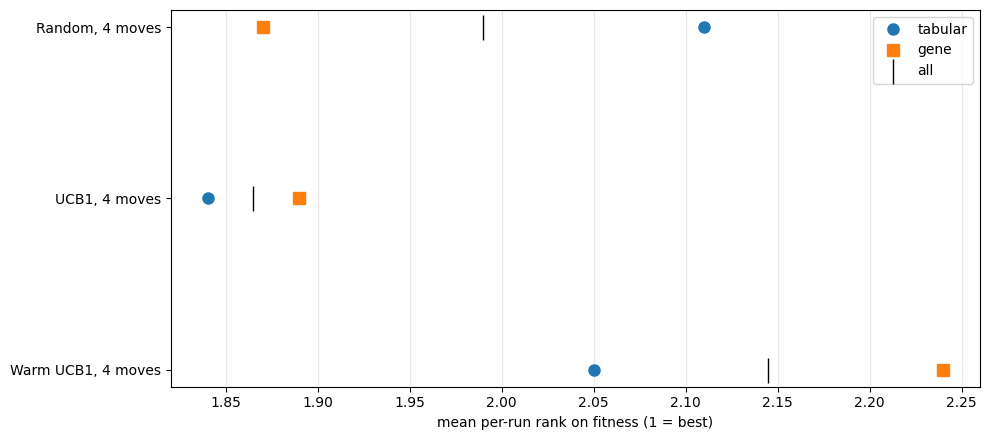

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
rk = mean_ranks(R, NAMES, "fit", False)
for grp, mk in (("tabular", "o"), ("gene", "s")):
    cols_g = [d for d in rk.columns if GROUP[d] == grp]
    if cols_g: ax.plot(rk[cols_g].mean(1).values, range(len(NAMES)), mk, label=grp, ms=8)
ax.plot(rk.mean(1).values, range(len(NAMES)), "k|", ms=18, label="all")
ax.set_yticks(range(len(NAMES))); ax.set_yticklabels(NAMES); ax.invert_yaxis()
ax.set_xlabel("mean per-run rank on fitness (1 = best)"); ax.legend(); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/v5_ranks.png", dpi=200); plt.show()

## 13. Download the results (everything except the caches and raw data)

In [16]:
zpath = f"{ROOT}/rl_doho_v5_rl_results.zip"
with zipfile.ZipFile(zpath, "w", zipfile.ZIP_DEFLATED) as z:
    for f in sorted(os.listdir(OUT_DIR)):
        if f.startswith("cache_") or f.endswith(".tmp") or os.path.isdir(f"{OUT_DIR}/{f}"): continue
        z.write(f"{OUT_DIR}/{f}", f"rl_doho_results_v5_rl/{f}")
print("Wrote", zpath, f"({os.path.getsize(zpath) / 1e6:.1f} MB)")
if IN_COLAB:
    from google.colab import files
    files.download(zpath)

Wrote /content/drive/MyDrive/rl_doho_v5_rl_results.zip (0.9 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. How to read the outcome
- **If any of H10a–d passes the success rule:** that change makes the controller worth having. Report it as a new RL-DOHO variant, together with the extra warm-up cost if it is warm-started.
- **If the moves differ (Kruskal–Wallis significant) but no learner beats random choice:** the learner is not picking up a real signal in the decisions it gets. Section 10 shows whether its choices track move quality.
- **If the moves do not differ:** there is little for any controller to learn. That supports the paper's conclusion that the gain comes from intervening, not from the choice of move.

In every case, report all four H10 results, as with H1–H9.